In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

label_names = ['negative', 'neutral', 'positive']
label_map = {"negative": 0, "neutral": 1, "positive": 2}
rando = 42

TXT_FILES = {
    "50agree": "Sentences_50Agree.txt",
    "66agree": "Sentences_66Agree.txt",
    "75agree": "Sentences_75Agree.txt",
    "allagree": "Sentences_AllAgree.txt",
}

AGREEMENT = "66agree"  # ← swap to 66agree / 75agree / allagree

# ── Parser ────────────────────────────────────────────────────────────────
def load_fpb_txt(filepath: str) -> pd.DataFrame:
    records = []
    with open(filepath, encoding="utf-8", errors="replace") as f:
        for lineno, raw in enumerate(f, 1):
            line = raw.strip()
            if not line:
                continue
            # split on the LAST @ to handle sentences that contain @ themselves
            idx = line.rfind("@")
            if idx == -1:
                print(f"[WARN] line {lineno}: no '@' separator found, skipping: {line[:60]}")
                continue
            sentence = line[:idx].strip()
            label    = line[idx+1:].strip().lower()
            if label not in label_map:
                print(f"[WARN] line {lineno}: unknown label '{label}', skipping")
                continue
            records.append({"sentence": sentence, "label": label_map[label]})

    df = pd.DataFrame(records)
    return df

# ── Load ──────────────────────────────────────────────────────────────────
filepath = TXT_FILES[AGREEMENT]
assert os.path.exists(filepath), f"File not found: {filepath} — make sure it's in the same folder as this notebook"

df = load_fpb_txt(filepath)
assert df["label"].isna().sum() == 0, "Unmapped labels found!"

print(f"Loaded: {filepath} — {len(df)} rows")
print("Shape:  ", df.shape)
print("Labels:\n", df["label"].value_counts().sort_index().to_dict())
print("\nSample:")
print(df.head(3).to_string(index=False))

# ── Split & vectorize ─────────────────────────────────────────────────────
X = df["sentence"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=rando, stratify=y
)
vectorizer = TfidfVectorizer(max_features=2000, stop_words="english", min_df=2, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print("\nTrain:", X_train_vec.shape, "| Test:", X_test_vec.shape)

Loaded: Sentences_66Agree.txt — 4217 rows
Shape:   (4217, 2)
Labels:
 {0: 514, 1: 2535, 2: 1168}

Sample:
                                                                                                                                                                                                      sentence  label
                                                                               According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .      1
                Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .      1
With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .      2

Train: (3373, 2000) | Test: (844, 200

##### Naive Bayes


MultinomialNB Results:
Accuracy: 0.7168
              precision    recall  f1-score   support

    negative       0.64      0.26      0.37       103
     neutral       0.74      0.93      0.83       507
    positive       0.63      0.45      0.53       234

    accuracy                           0.72       844
   macro avg       0.67      0.55      0.58       844
weighted avg       0.70      0.72      0.69       844



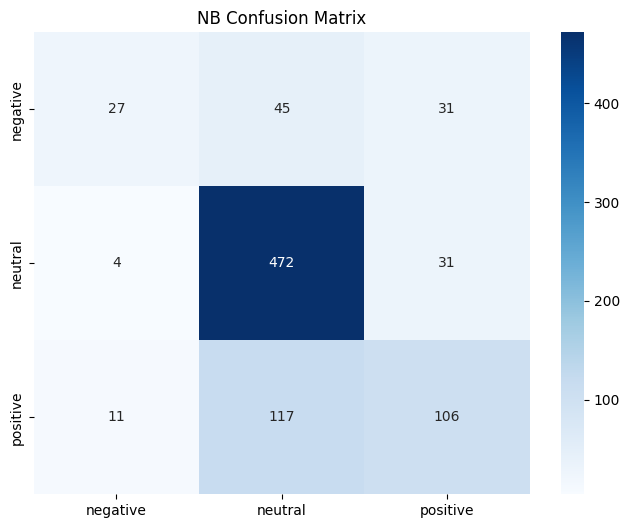

In [2]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB(alpha=1.0, class_prior=None) 
model_nb.fit(X_train_vec, y_train)
y_pred_nb = model_nb.predict(X_test_vec)

print("\nMultinomialNB Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(classification_report(y_test, y_pred_nb, target_names=label_names))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('NB Confusion Matrix')
# plt.savefig('twitter_nb_cm.png', dpi=300)
plt.show()


##### Logistic Regression


Logistic Regression Results:
Accuracy: 0.7595
              precision    recall  f1-score   support

    negative       0.72      0.33      0.45       103
     neutral       0.77      0.95      0.85       507
    positive       0.75      0.54      0.63       234

    accuracy                           0.76       844
   macro avg       0.75      0.61      0.64       844
weighted avg       0.76      0.76      0.74       844



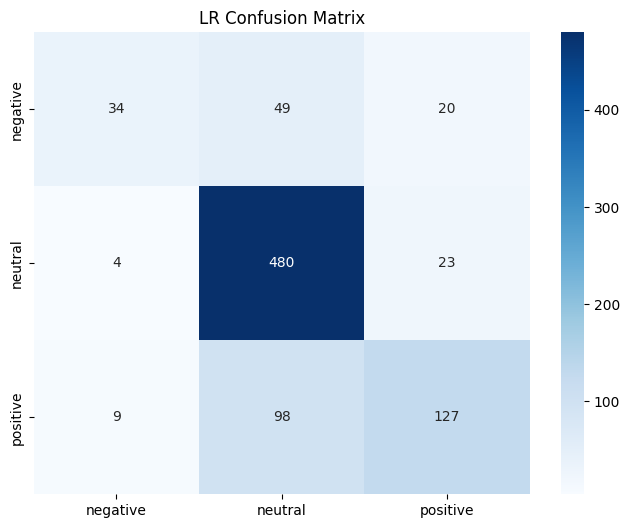

In [3]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000, random_state=67)
model_lr.fit(X_train_vec, y_train)
y_pred_lr = model_lr.predict(X_test_vec)

print("\nLogistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=label_names))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('LR Confusion Matrix')
# plt.savefig('twitter_lr_cm.png', dpi=300)
plt.show()

##### SVM


SVM Results:
Accuracy: 0.7725
              precision    recall  f1-score   support

    negative       0.66      0.48      0.55       103
     neutral       0.80      0.92      0.85       507
    positive       0.73      0.59      0.65       234

    accuracy                           0.77       844
   macro avg       0.73      0.66      0.69       844
weighted avg       0.76      0.77      0.76       844



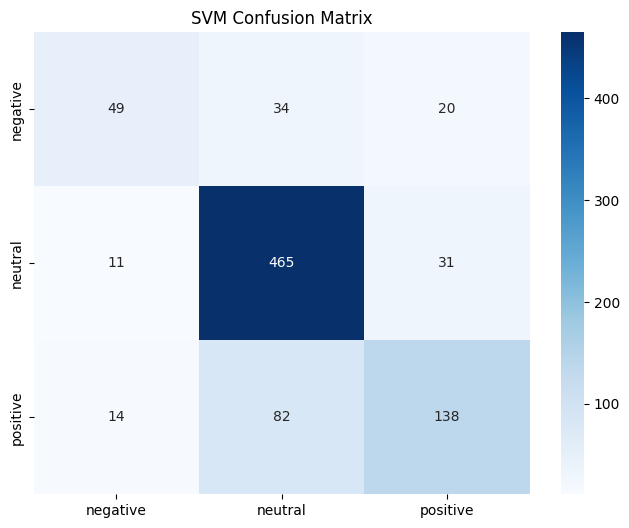

In [4]:
from sklearn.svm import SVC

model_svm = SVC(kernel='linear', random_state=67, probability=True)
model_svm.fit(X_train_vec, y_train)
y_pred_svm = model_svm.predict(X_test_vec)

print("\nSVM Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=label_names))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('SVM Confusion Matrix')
# plt.savefig('twitter_svm_cm.png', dpi=300)
plt.show()

##### XGBoost

Tuned XGBoost:
Accuracy: 0.7678
              precision    recall  f1-score   support

    negative       0.71      0.39      0.50       103
     neutral       0.75      0.97      0.85       507
    positive       0.85      0.50      0.63       234

    accuracy                           0.77       844
   macro avg       0.77      0.62      0.66       844
weighted avg       0.78      0.77      0.75       844



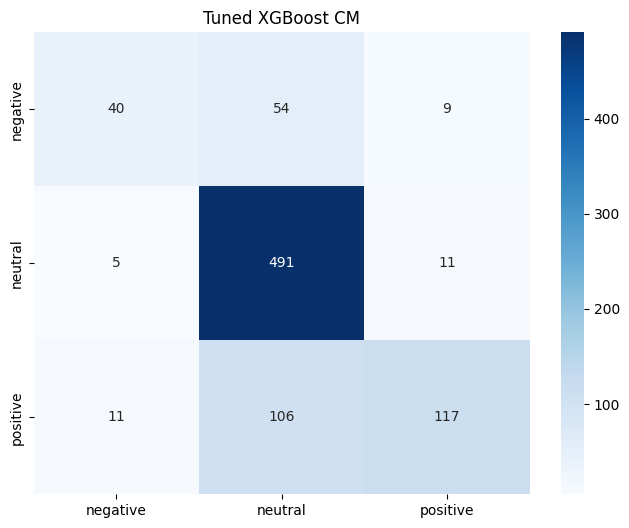

In [5]:
import xgboost as xgb

scale_pos_weight = {0: 1.0, 1: 0.6, 2: 1.2}  # Downweight neutral, up pos/neg
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=3,        # Shallower to prevent overfitting
    min_child_weight=5, # Higher for small data
    learning_rate=0.05, # Slower learning
    n_estimators=300,   # More trees, slow learning
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,      # L1 reg
    reg_lambda=0.1,     # L2 reg
    random_state=rando,
    eval_metric='mlogloss'
)
model.fit(X_train_vec, y_train, verbose=False)

y_pred = model.predict(X_test_vec)
print("Tuned XGBoost:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=label_names))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Tuned XGBoost CM')
# plt.savefig('xgb_tuned_cm.png', dpi=300)
plt.show()

##### LightGBM

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[150]	valid_0's multi_logloss: 0.654182
LightGBM Results:
Accuracy: 0.7464
              precision    recall  f1-score   support

    negative       0.75      0.40      0.52       103
     neutral       0.74      0.96      0.83       507
    positive       0.80      0.44      0.56       234

    accuracy                           0.75       844
   macro avg       0.76      0.60      0.64       844
weighted avg       0.75      0.75      0.72       844



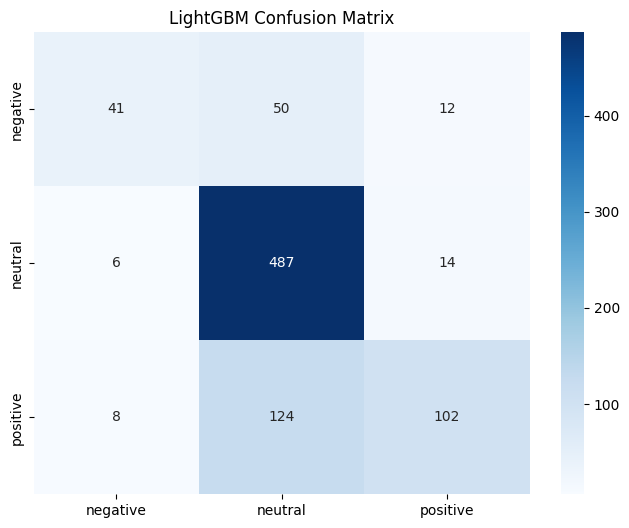

In [6]:
import lightgbm as lgb

train_data = lgb.Dataset(X_train_vec, label=y_train)
test_data = lgb.Dataset(X_test_vec, label=y_test, reference=train_data)

# TUNED params for imbalance + small data
params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'max_depth': 3,
    'num_leaves': 15,      # Conservative
    'learning_rate': 0.05,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'min_data_in_leaf': 20, # Anti-overfit
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'is_unbalance': True,   # Handles neutral skew!
    'verbose': -1,
    'random_state': rando
}

model = lgb.train(params, train_data, num_boost_round=150, valid_sets=[test_data], callbacks=[lgb.early_stopping(10)])

# Predict
y_pred = np.argmax(model.predict(X_test_vec), axis=1)
print("LightGBM Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=label_names))

# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('LightGBM Confusion Matrix')
# plt.savefig('lgb_cm.png', dpi=300)
plt.show()

##### Sentiment Metrics Results

In [7]:
from sentiment_metrics import compute_all_metrics
metrics = compute_all_metrics(y_true=y_test.tolist(), y_pred=y_pred_nb.tolist())
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"Macro F1: {metrics['macro_f1']:.4f}")
print(f"S-MAE:    {metrics['s_mae']:.4f}")
for cls, vals in metrics['per_class'].items():
    print(f"  {cls}: P={vals['precision']:.2f} R={vals['recall']:.2f} F1={vals['f1']:.2f}")

Accuracy: 0.7168
Macro F1: 0.5757
S-MAE:    0.3329
  negative: P=0.64 R=0.26 F1=0.37
  neutral: P=0.74 R=0.93 F1=0.83
  positive: P=0.63 R=0.45 F1=0.53


In [8]:
# ── Unified evaluation using sentiment_metrics.py ──────────────────────────
from sentiment_metrics import compute_all_metrics

models_preds = {
    "Naive Bayes":         y_pred_nb,
    "Logistic Regression": y_pred_lr,
    "SVM":                 y_pred_svm,
    "LightGBM":            y_pred,      # LightGBM uses y_pred directly
}

for model_name, y_pred_model in models_preds.items():
    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    
    metrics = compute_all_metrics(
        y_true=y_test.tolist(),
        y_pred=y_pred_model.tolist(),
        # int_label_scheme="phrasebank" is default (0=neg, 1=neu, 2=pos)
    )
    
    print(f"Accuracy : {metrics['accuracy']:.4f}")
    print(f"Macro F1 : {metrics['macro_f1']:.4f}")
    print(f"S-MAE    : {metrics['s_mae']:.4f}")
    print("\nPer-class breakdown:")
    for cls, vals in metrics['per_class'].items():
        print(f"  {cls:10s}  P={vals['precision']:.3f}  R={vals['recall']:.3f}  F1={vals['f1']:.3f}  support={int(vals['support'])}")


  Naive Bayes
Accuracy : 0.7168
Macro F1 : 0.5757
S-MAE    : 0.3329

Per-class breakdown:
  negative    P=0.643  R=0.262  F1=0.372  support=103
  neutral     P=0.744  R=0.931  F1=0.827  support=507
  positive    P=0.631  R=0.453  F1=0.527  support=234

  Logistic Regression
Accuracy : 0.7595
Macro F1 : 0.6429
S-MAE    : 0.2749

Per-class breakdown:
  negative    P=0.723  R=0.330  F1=0.453  support=103
  neutral     P=0.766  R=0.947  F1=0.847  support=507
  positive    P=0.747  R=0.543  F1=0.629  support=234

  SVM
Accuracy : 0.7725
Macro F1 : 0.6870
S-MAE    : 0.2678

Per-class breakdown:
  negative    P=0.662  R=0.476  F1=0.554  support=103
  neutral     P=0.800  R=0.917  F1=0.855  support=507
  positive    P=0.730  R=0.590  F1=0.652  support=234

  LightGBM
Accuracy : 0.7464
Macro F1 : 0.6388
S-MAE    : 0.2773

Per-class breakdown:
  negative    P=0.745  R=0.398  F1=0.519  support=103
  neutral     P=0.737  R=0.961  F1=0.834  support=507
  positive    P=0.797  R=0.436  F1=0.564  sup